# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

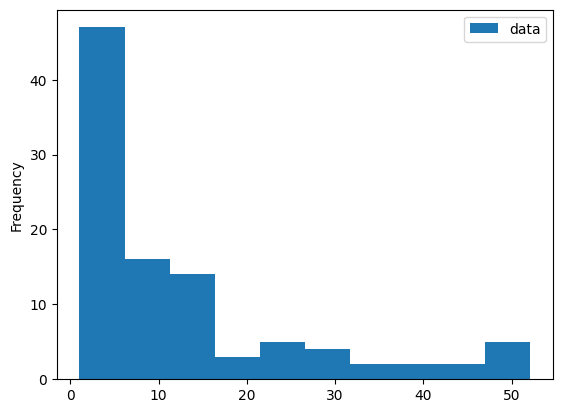

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

#The histogram is helpful because it shows the full distribution of prices. You can see where most of the drug prices fall and how the values spread out overall. In this case, it looks like most drugs are on the lower end, with fewer and fewer as prices get higher. The downside is that histograms depend a lot on how the bins are set, so sometimes the picture can look slightly different depending on how it’s formatted.

<Axes: >

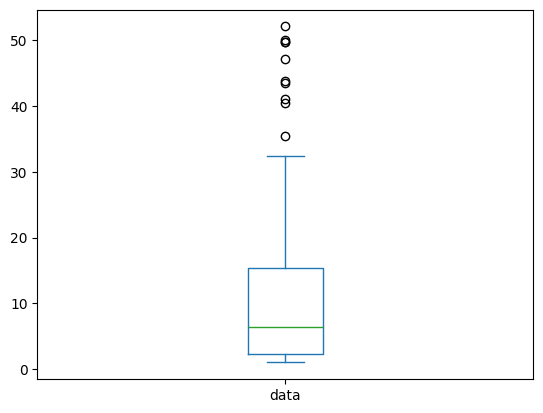

In [3]:
df.plot.box()

#The boxplot is more of a summary view. It shows the median, the middle 50% of the data, and any outliers. This makes it really useful for understanding the more expensive drugs since those show up clearly as outliers or part of the upper range. The only issue is that it doesn’t show the full shape of the data, so you lose some detail about how the values are distributed.

If I had to choose one, I would probably go with the boxplot because the question is more focused on understanding higher priced drugs compared to the rest, and the boxplot shows that more directly.

#To make the graphs better, I would add labels and a title to both so it’s clearer what we’re looking at. For the histogram, I would also consider adding a line for the median or 75th percentile to connect it back to the question. Using a log scale could also help since the data is skewed. For the boxplot, I would maybe make it horizontal so it’s easier to read.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [6]:
!pip install xlrd


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1, engine="xlrd")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [21]:
#Basic Summary Statistics
df.info()
df.describe()

print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode().iloc[0])

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

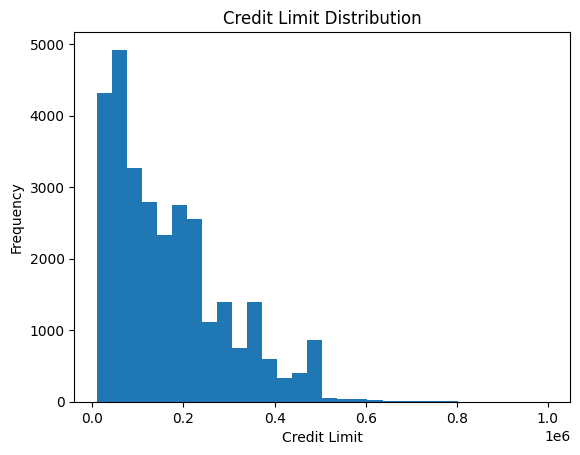

In [12]:
#Histograms (Key Features)
df['LIMIT_BAL'].plot.hist(bins=30, title="Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.show()

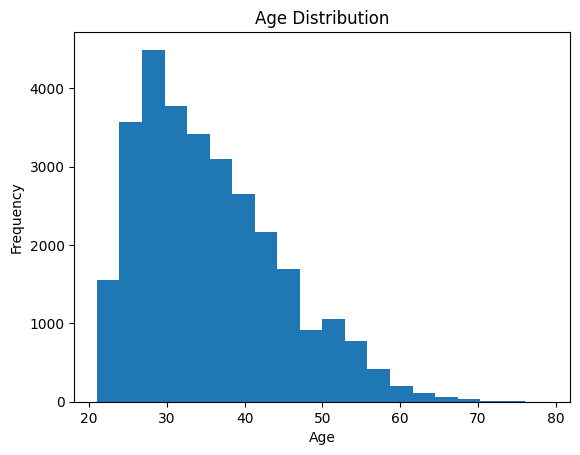

In [14]:
#Age Distribution
df['AGE'].plot.hist(bins=20, title="Age Distribution")
plt.xlabel("Age")
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 50.5 MB/s  0:00:006m0:00:01

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


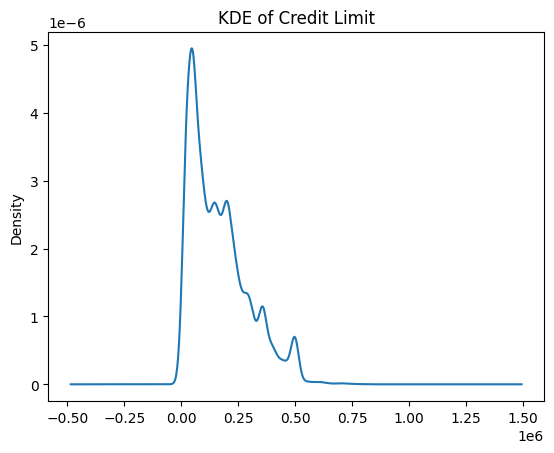

In [16]:
#KDE Plot (Smoothed View)
!pip install scipy
df['LIMIT_BAL'].plot.kde(title="KDE of Credit Limit")
plt.show()

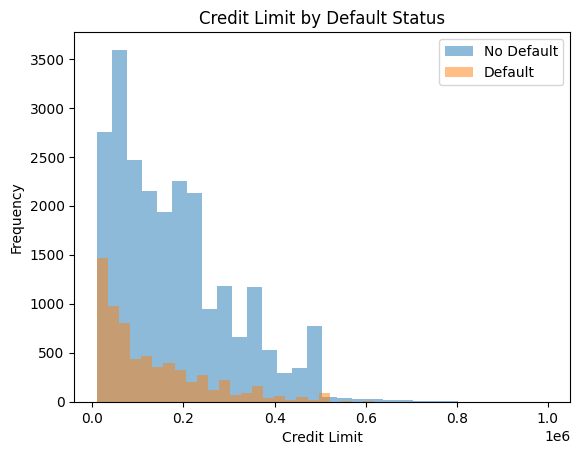

In [18]:
#Grouped Histograms (Default vs Non-Default)
df[df['default payment next month'] == 0]['LIMIT_BAL'].plot.hist(alpha=0.5, bins=30, label="No Default")
df[df['default payment next month'] == 1]['LIMIT_BAL'].plot.hist(alpha=0.5, bins=30, label="Default")

plt.legend()
plt.title("Credit Limit by Default Status")
plt.xlabel("Credit Limit")
plt.show()

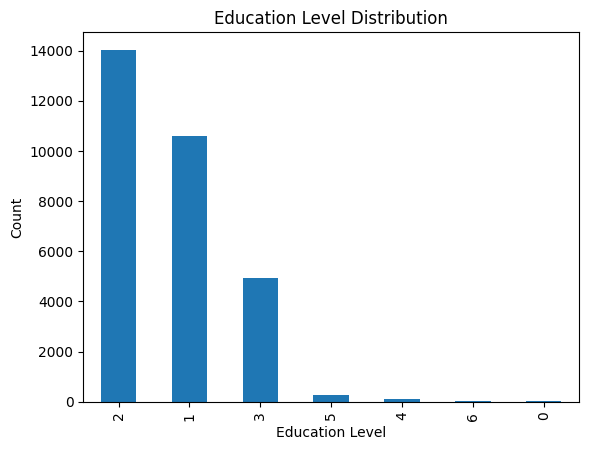

In [19]:
#Bar Plot (Categorical Variable)
df['EDUCATION'].value_counts().plot(kind='bar', title="Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()

## Are the data usable?

Overall, yes! the dataset is usable and seems pretty realistic. It includes both numerical and categorical variables, and there aren’t any major missing data issues, which is good. Since it comes from real credit card customer data, it also makes sense in terms of real-world financial behavior, so it should work well for credit risk analysis.

## Shape of distributions

Most of the numerical features are not normally distributed.

For example, LIMIT_BAL (credit limit) is heavily right Skewed, meaning most people have relatively low credit limits and only a small group have very high ones. AGE is a bit closer to a normal distribution but still slightly skewed. Other variables like bill amounts and payment amounts are also very skewed.

So overall, the dataset doesn’t follow a normal distribution. It’s mostly skewed.

## Outliers

There are definitely some outliers in the data.

The biggest ones are in LIMIT_BAL, where a few customers have much higher credit limits than most others. You can also see outliers in some of the bill and payment amount columns, where values get really large compared to the rest.

These don’t look like errors though. They’re actually pretty expected for financial data, since some customers naturally have much higher balances or credit limits than others.

## Group comparison (default vs non default)

From the grouped histograms, there’s a noticeable difference between the two groups.

Customers who default tend to have lower credit limits overall, while non-default customers are more spread out and include higher credit limits.

This suggests that credit limit might be somewhat related to default risk, but it definitely isn’t the only factor involved.

## Min and max values

The range of values is pretty wide across the dataset.

LIMIT_BAL goes from fairly low credit limits (around 10,000) all the way up to 500,000 or more.
AGE ranges from people in their 20s up to around their 70s.

This shows that the dataset includes a pretty diverse group of customers.

## Effect of bin size

Changing the bin size in histograms really affects how the data looks.

Smaller bins show more detail, but they can also make the graph look a bit noisy or cluttered. Larger bins smooth everything out, but you lose some of the smaller patterns in the data.

For example, with LIMIT_BAL, smaller bins show more clustering in the lower credit ranges, while larger bins make the distribution look smoother but less detailed.

## Overall conclusion

Overall, this dataset works well for analysis. Most of the variables are skewed rather than normally distributed, which actually makes sense for financial data. There are outliers, but they seem meaningful rather than being data errors.

It looks like a solid dataset for predicting credit card default, although it might need some preprocessing like scaling or handling class imbalance before building models.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

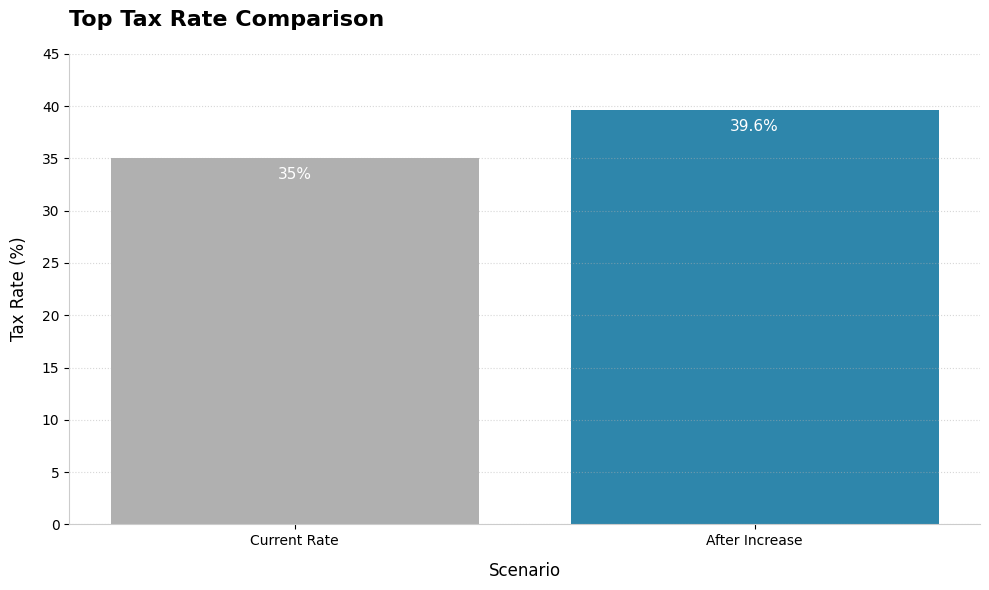

In [23]:
labels = ['Current Rate', 'After Increase']
values = [35, 39.6]

plt.figure(figsize=(10, 6))


colors = ['#B0B0B0', '#2E86AB']
plt.bar(labels, values, color=colors)

plt.title('Top Tax Rate Comparison', 
          fontsize=16, fontweight='bold', loc='left', pad=20)


plt.xlabel('Scenario', fontsize=12, labelpad=10)
plt.ylabel('Tax Rate (%)', fontsize=12, labelpad=10)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')


plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.ylim(0, 45)

for i, v in enumerate(values):
    plt.text(i, v - 2, f'{v}%', ha='center', color='white', fontsize=11)

plt.tight_layout()
plt.show()